# UJI PERILAKU — BASELINE v2 (Tahap 0.5e)

Menjalankan **Uji B (uji penuh, 2019–2025)** dan **Uji P5 (subsistem wisatawan, 2016–2025)** dengan
LPE 0,27726 dan LPD 0,207945 (hasil koreksi penurunan pada Tahap 0), lalu menghitung statistik
Barlas (1989): uji tren, E1, E2, DC, proporsi ketimpangan U1–U3, dan MAPE, dalam dua versi
(dengan dan tanpa COVID 2020–2021).

**Prasyarat:** `Uji_B.mdl` dan `Uji_Parsial_P5.mdl` sudah memakai konstanta baru.

**Catatan:** data pembanding diketik langsung dari sheet *Data Tahunan* Master Data, supaya
notebook ini tidak bergantung pada file Excel. Seri wisatawan untuk P5 memakai seri sambungan
(faktor 2,2997 untuk 2015–2018).

Urutan statistik mengikuti keputusan protokol: **tren → E1 → E2 → DC**. Bila tren gagal,
E1 dan E2 tidak ditafsirkan (Barlas, 1989).

In [1]:
!pip install pysd openpyxl matplotlib scipy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 12.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.2/150.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.5/919.5 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.4/268.4 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 5.5 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pysd
from scipy import stats

warnings.filterwarnings("ignore")

# --- sesuaikan path bila perlu ---
FOLDER = Path("/content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[02] Uji Perilaku/Kalibrasi")
FILE_B  = FOLDER / "/content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[02] Uji Perilaku/Kalibrasi/Uji B.mdl"
FILE_P5 = FOLDER / "/content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[02] Uji Perilaku/Kalibrasi/Uji Parsial P5.mdl"
FOLDER.mkdir(parents=True, exist_ok=True)

for f in (FILE_B, FILE_P5):
    if not f.exists():
        from google.colab import files
        print(f"'{f.name}' belum ada, silakan upload:")
        files.upload()

## Data pembanding (Master Data, sheet *Data Tahunan*, 2015–2025)

In [5]:
TAHUN = np.arange(2015, 2026)
DATA = pd.DataFrame({
 "Jumlah Wisatawan": [6413735,6551294,6644412,7996959,20520104,19610135,22849394.5,25755726,30542580,38134536,40695654],
 "Jumlah Hotel dan Akomodasi": [1165,1170,1179,1617,1817,1848,1696,1818,1820,2000,2291],
 "Jumlah Objek Daya Tarik Wisata": [165,158,171,177,189,180,170,183,201,218,201],
 "Tenaga Kerja Pariwisata": [254537,263878,273563,354684,334784,313840,310755,395284,359340,350946,364994],
 "Lahan Terbangun": [43037.00491,44561.0784555117,50223.957001398,56624.3602289948,63480.0442236269,
                     58962.0411105434,59887.5260314565,57709.075808398,75624.403529316,73511.574651116,55029.5352961885],
 "TPK": [0.3489,0.3772,0.4508,0.4511,0.4534,0.2890,0.2748,0.4499,0.4477,0.4217,0.3807],   # TPK BPS / 100
 "PDRB Sektor Pariwisata": [10131.09,10694.03,11347.59,12100.99,13104.38,10926.83,12097.19,13672.58,14809.20,15873.81,16947.62],
 "Investasi Sektor Pariwisata": [53.0896,373.8424,165.3915,568.3341,741.4483,489.6932,848.8042,463.5886,1175.2552,712.2835,1325.950399],
 "Total Malam Menginap": [5698325,6097324,10899900,10293319,13363923,4753098,7379577,9267217,11417702,11503540,11954114],
}, index=TAHUN)

# Seri sambungan untuk P5 (patahan metode BPS 2018/2019)
FAKTOR = 2.2997
JW_SAMBUNG = DATA["Jumlah Wisatawan"].copy()
JW_SAMBUNG.loc[2015:2018] *= FAKTOR
JW_SAMBUNG.round(0).to_frame("Data sambungan").T

,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Data sambungan,14749666.0,15066011.0,15280154.0,18390607.0,20520104.0,19610135.0,22849394.0,25755726.0,30542580.0,38134536.0,40695654.0


## Fungsi statistik

- **Tren:** t = |b_S − b_A| ÷ √(Var b_A + Var b_S); t tabel = T.INV.2T(0,05; 2n−4)
- **E1** = |S̄ − Ā| ÷ |Ā| (pedoman Barlas ≤ 0,05)
- **E2** = |S_S − S_A| ÷ S_A dengan STDEV.P (pedoman ≤ 0,30)
- **DC** = S_E ÷ (S_A + S_S); Baik < 0,4; Cukup 0,4–0,7; Kurang > 0,7
- **U1, U2, U3** = bias, variasi, kovariasi, masing-masing dibagi MSE (tanpa ambang)

In [6]:
def statistik(sim, act, t):
    sim, act, t = np.asarray(sim, float), np.asarray(act, float), np.asarray(t, float)
    e = sim - act
    SA, SS, SE = act.std(), sim.std(), e.std()          # STDEV.P
    r = np.corrcoef(sim, act)[0, 1]
    mse = np.mean(e ** 2)
    la, ls = stats.linregress(t, act), stats.linregress(t, sim)
    n = len(t)
    t_hit = abs(ls.slope - la.slope) / np.sqrt(la.stderr ** 2 + ls.stderr ** 2)
    t_tab = stats.t.ppf(0.975, 2 * n - 4)
    if np.sign(ls.slope) != np.sign(la.slope):
        tren = "Berlawanan arah"
    elif t_hit > t_tab:
        tren = "Berbeda nyata"
    else:
        tren = "Tidak berbeda nyata"
    return {"n": n, "Kemiringan data": la.slope, "Kemiringan simulasi": ls.slope,
            "t hitung": t_hit, "t tabel": t_tab, "Tren": tren,
            "E1": abs(sim.mean() - act.mean()) / abs(act.mean()),
            "E2": abs(SS - SA) / SA,
            "DC": SE / (SA + SS), "r": r,
            "U1": (sim.mean() - act.mean()) ** 2 / mse,
            "U2": (SS - SA) ** 2 / mse,
            "U3": 2 * (1 - r) * SS * SA / mse,
            "MAPE (%)": 100 * np.mean(np.abs(e / act))}


def jalankan(berkas, kolom, tahun_awal, tahun_akhir=2025):
    m = pysd.read_vensim(str(berkas))
    r = m.run(return_columns=kolom, return_timestamps=list(range(tahun_awal, tahun_akhir + 1)))
    return r.apply(lambda s: np.real(s.astype(complex)))

## Jalankan Uji B dan Uji P5

In [7]:
m = pysd.read_vensim(str(FILE_B))
NAMA_TPK = [k for k in m.namespace if "TPK" in k and "Ambang" not in k][0]
KOLOM_B = ["Jumlah Wisatawan", "Jumlah Hotel dan Akomodasi", "Jumlah Objek Daya Tarik Wisata",
           "Tenaga Kerja Pariwisata", "Lahan Terbangun", NAMA_TPK, "PDRB Sektor Pariwisata",
           "Investasi Sektor Pariwisata", "Total Malam Menginap"]
PETA = {NAMA_TPK: "TPK"}          # nama kolom simulasi -> nama baris data

sim_B  = jalankan(FILE_B,  KOLOM_B, 2019)
sim_P5 = jalankan(FILE_P5, ["Jumlah Wisatawan"], 2016)

print("Cek P5: JW 2017 =", f"{sim_P5['Jumlah Wisatawan'][2017]:,.0f}", " (harus ≈ 16.035.938)")
print("Cek B : JW 2025 =", f"{sim_B['Jumlah Wisatawan'][2025]:,.0f}")
sim_B.round(2)

Cek P5: JW 2017 = 16,035,938  (harus ≈ 16.035.938)
Cek B : JW 2025 = 29,747,841


,Jumlah Wisatawan,Jumlah Hotel dan Akomodasi,Jumlah Objek Daya Tarik Wisata,Tenaga Kerja Pariwisata,Lahan Terbangun,"""Tingkat Penghunian Kamar (TPK)""",PDRB Sektor Pariwisata,Investasi Sektor Pariwisata,Total Malam Menginap
time,,,,,,,,,
2019,20520100.00,1817.00,189.00,334784.00,63480.00,0.23,8545.55,417.17,6026273.20
2020,21854934.12,1726.15,189.38,324740.48,65698.56,0.25,9101.44,444.31,6418282.75
2021,23265200.04,1639.84,190.02,314998.27,67974.54,0.29,9688.74,472.98,6832444.85
2022,24755046.24,1569.49,190.94,305548.32,70309.12,0.32,10309.19,503.27,7269977.81
2023,26328899.62,1540.57,192.13,296381.87,72704.77,0.34,10964.61,535.26,7732181.72
2024,27991479.73,1549.10,193.59,287490.41,75161.17,0.36,11656.99,569.06,8220442.60
2025,29747841.39,1588.56,195.34,278865.70,77677.66,0.38,12388.42,604.77,8736244.92


## Hitung statistik (dua versi COVID)

In [8]:
hasil, seri = [], {}
for uji, sim, kolom in [("B", sim_B, KOLOM_B), ("P5", sim_P5, ["Jumlah Wisatawan"])]:
    tahun = sim.index.values
    for c in kolom:
        nama = PETA.get(c, c).strip('"')
        if uji == "P5" and c == "Jumlah Wisatawan":
            act = JW_SAMBUNG.loc[tahun].values          # P5 memakai seri sambungan
        else:
            act = DATA[nama].loc[tahun].values
        s = sim[c].values
        seri[f"{uji} {nama}"] = pd.DataFrame({"Tahun": tahun, "Data": act, "Simulasi": s})
        for versi, mask in [("Dengan COVID", np.ones(len(tahun), bool)),
                            ("Tanpa COVID", ~np.isin(tahun, [2020, 2021]))]:
            hasil.append({"Uji": uji, "Variabel": nama, "Versi": versi,
                          **statistik(s[mask], act[mask], tahun[mask])})

tabel = pd.DataFrame(hasil)
tabel[["Uji", "Variabel", "Versi", "Tren", "E1", "E2", "DC", "U1", "U2", "U3", "MAPE (%)"]].round(4)

,Uji,Variabel,Versi,Tren,E1,E2,DC,U1,U2,U3,MAPE (%)
0,B,Jumlah Wisatawan,Dengan COVID,Berbeda nyata,0.1194,0.6064,0.4482,0.3237,0.6374,0.0389,12.0640
1,B,Jumlah Wisatawan,Tanpa COVID,Berbeda nyata,0.1690,0.5808,0.4258,0.5731,0.3945,0.0325,14.2362
2,B,Jumlah Hotel dan Akomodasi,Dengan COVID,Berlawanan arah,0.1399,0.4685,0.8228,0.5779,0.0584,0.3637,13.1619
3,B,Jumlah Hotel dan Akomodasi,Tanpa COVID,Berlawanan arah,0.1725,0.4406,0.8082,0.6758,0.0396,0.2846,16.4458
4,B,Jumlah Objek Daya Tarik Wisata,Dengan COVID,Tidak berbeda nyata,0.0012,0.8550,0.7855,0.0003,0.9033,0.0964,5.6795
5,B,Jumlah Objek Daya Tarik Wisata,Tanpa COVID,Tidak berbeda nyata,0.0313,0.8193,0.7568,0.2499,0.6307,0.1194,4.5536
6,B,Tenaga Kerja Pariwisata,Dengan COVID,Berlawanan arah,0.1182,0.3280,0.8860,0.4991,0.0245,0.4763,12.3913
7,B,Tenaga Kerja Pariwisata,Tanpa COVID,Berlawanan arah,0.1674,0.0327,0.8222,0.7789,0.0001,0.2210,16.3801
8,B,Lahan Terbangun,Dengan COVID,Tidak berbeda nyata,0.1099,0.3627,0.6619,0.4286,0.0640,0.5073,13.4320
9,B,Lahan Terbangun,Tanpa COVID,Tidak berbeda nyata,0.1044,0.4108,0.7254,0.3381,0.0841,0.5778,13.8190


## Penilaian lolos / tidak lolos

Mengikuti urutan Barlas (1989): **tren → E1 → E2 → DC**.

- **Tren** lolos bila arahnya sama **dan** t hitung ≤ t tabel ("Tidak berbeda nyata").
- **E1** lolos bila ≤ 0,05; **E2** lolos bila ≤ 0,30. Keduanya **tidak ditafsirkan** bila tren tidak lolos, karena Barlas menyatakan kedua ukuran itu kehilangan makna saat komponen tren berbeda.
- **DC** dikategorikan Baik < 0,4; Cukup 0,4–0,7; Kurang > 0,7, dan dipakai sebagai ringkasan, bukan uji.
- **Komponen dominan** menunjukkan U1 (bias), U2 (variasi), atau U3 (kovariasi) yang terbesar. U1 dan U2 berarti galat sistematis, U3 berarti galat tidak sistematis.

In [9]:
def penilaian(t):
    t = t.copy()
    t["Arah kemiringan"] = np.where(np.sign(t["Kemiringan simulasi"]) == np.sign(t["Kemiringan data"]),
                                    "Searah", "Berlawanan")
    lolos_tren = t["Tren"] == "Tidak berbeda nyata"
    t["Status Tren"] = np.where(lolos_tren, "Lolos", "Tidak lolos")
    t["Status E1 (<=0,05)"] = np.where(~lolos_tren, "Tidak ditafsirkan",
                                       np.where(t["E1"] <= 0.05, "Lolos", "Tidak lolos"))
    t["Status E2 (<=0,30)"] = np.where(~lolos_tren, "Tidak ditafsirkan",
                                       np.where(t["E2"] <= 0.30, "Lolos", "Tidak lolos"))
    t["Kategori DC"] = np.where(t["DC"] < 0.4, "Baik", np.where(t["DC"] <= 0.7, "Cukup", "Kurang"))
    t["Komponen dominan"] = t[["U1", "U2", "U3"]].idxmax(axis=1).map(
        {"U1": "U1 (bias)", "U2": "U2 (variasi)", "U3": "U3 (kovariasi)"})
    urut = ["Uji", "Variabel", "Versi", "Arah kemiringan", "t hitung", "t tabel", "Tren", "Status Tren",
            "E1", "Status E1 (<=0,05)", "E2", "Status E2 (<=0,30)", "DC", "Kategori DC",
            "U1", "U2", "U3", "Komponen dominan", "MAPE (%)", "r", "n",
            "Kemiringan data", "Kemiringan simulasi"]
    return t[urut]


tabel = penilaian(tabel)
tabel[["Uji", "Variabel", "Versi", "Status Tren", "E1", "Status E1 (<=0,05)",
       "E2", "Status E2 (<=0,30)", "DC", "Kategori DC", "Komponen dominan"]].round(4)

,Uji,Variabel,Versi,Status Tren,E1,"Status E1 (<=0,05)",E2,"Status E2 (<=0,30)",DC,Kategori DC,Komponen dominan
0,B,Jumlah Wisatawan,Dengan COVID,Tidak lolos,0.1194,Tidak ditafsirkan,0.6064,Tidak ditafsirkan,0.4482,Cukup,U2 (variasi)
1,B,Jumlah Wisatawan,Tanpa COVID,Tidak lolos,0.1690,Tidak ditafsirkan,0.5808,Tidak ditafsirkan,0.4258,Cukup,U1 (bias)
2,B,Jumlah Hotel dan Akomodasi,Dengan COVID,Tidak lolos,0.1399,Tidak ditafsirkan,0.4685,Tidak ditafsirkan,0.8228,Kurang,U1 (bias)
3,B,Jumlah Hotel dan Akomodasi,Tanpa COVID,Tidak lolos,0.1725,Tidak ditafsirkan,0.4406,Tidak ditafsirkan,0.8082,Kurang,U1 (bias)
4,B,Jumlah Objek Daya Tarik Wisata,Dengan COVID,Lolos,0.0012,Lolos,0.8550,Tidak lolos,0.7855,Kurang,U2 (variasi)
5,B,Jumlah Objek Daya Tarik Wisata,Tanpa COVID,Lolos,0.0313,Lolos,0.8193,Tidak lolos,0.7568,Kurang,U2 (variasi)
6,B,Tenaga Kerja Pariwisata,Dengan COVID,Tidak lolos,0.1182,Tidak ditafsirkan,0.3280,Tidak ditafsirkan,0.8860,Kurang,U1 (bias)
7,B,Tenaga Kerja Pariwisata,Tanpa COVID,Tidak lolos,0.1674,Tidak ditafsirkan,0.0327,Tidak ditafsirkan,0.8222,Kurang,U1 (bias)
8,B,Lahan Terbangun,Dengan COVID,Lolos,0.1099,Tidak lolos,0.3627,Tidak lolos,0.6619,Cukup,U3 (kovariasi)
9,B,Lahan Terbangun,Tanpa COVID,Lolos,0.1044,Tidak lolos,0.4108,Tidak lolos,0.7254,Kurang,U3 (kovariasi)


## Simpan Excel

In [10]:
berkas = FOLDER / "hasil_uji_perilaku_baseline_v2.xlsx"
with pd.ExcelWriter(berkas) as w:
    tabel.round(6).to_excel(w, sheet_name="Statistik", index=False)
    sim_B.round(4).to_excel(w, sheet_name="B Uji penuh")
    sim_P5.round(4).to_excel(w, sheet_name="P5 Subsistem Wisatawan")
    DATA.round(4).to_excel(w, sheet_name="Data Pembanding")
    pd.DataFrame({"Tahun": TAHUN, "Data asli": DATA["Jumlah Wisatawan"].values,
                  "Data sambungan": JW_SAMBUNG.values}).to_excel(w, sheet_name="Seri Wisatawan", index=False)
    for nama, df in seri.items():
        df.round(4).to_excel(w, sheet_name=nama[:31], index=False)
print("Tersimpan:", berkas)

Tersimpan: /content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[02] Uji Perilaku/Kalibrasi/hasil_uji_perilaku_baseline_v2.xlsx


## Grafik data vs simulasi

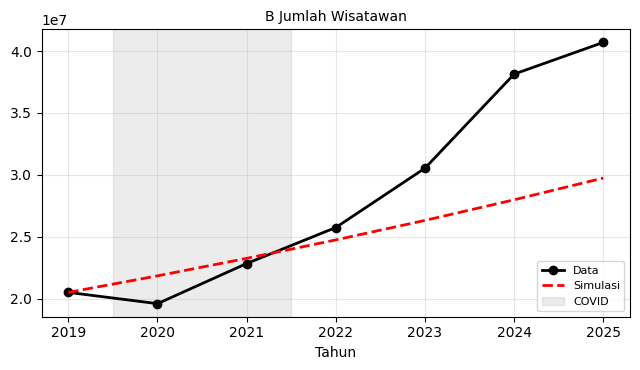

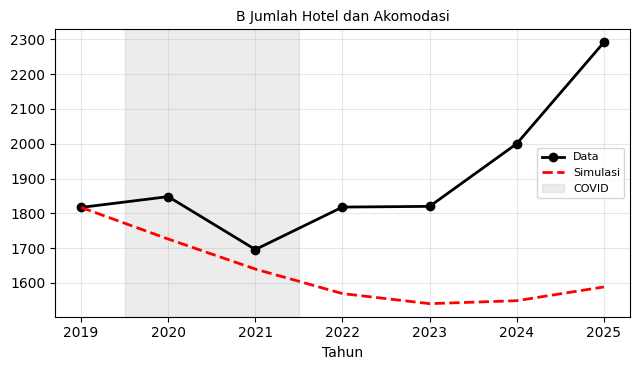

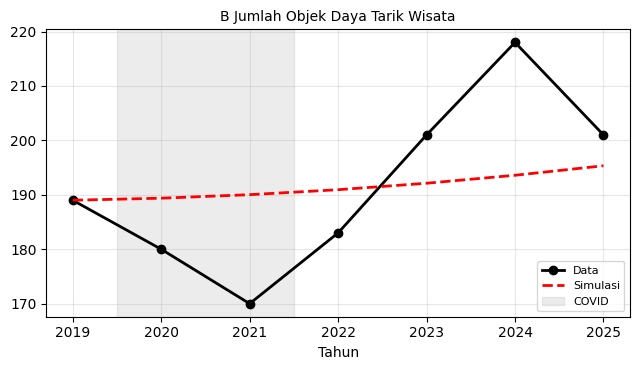

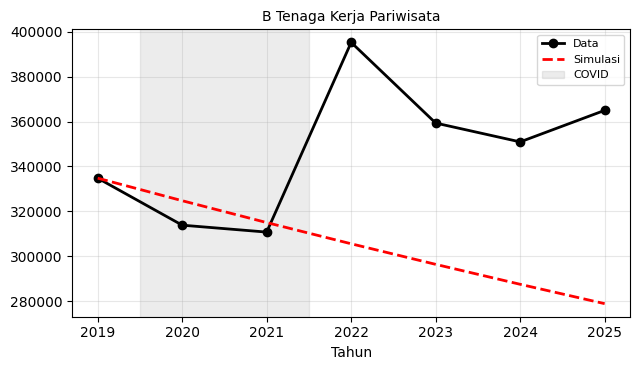

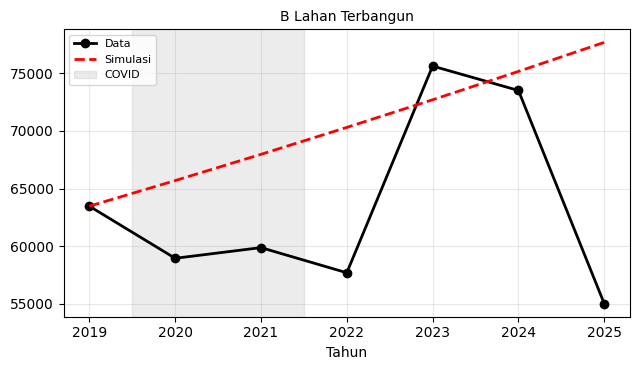

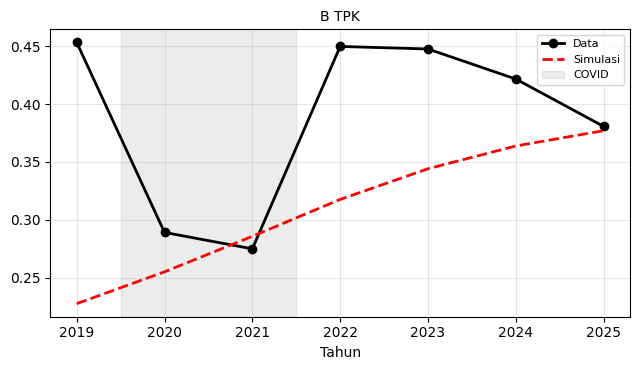

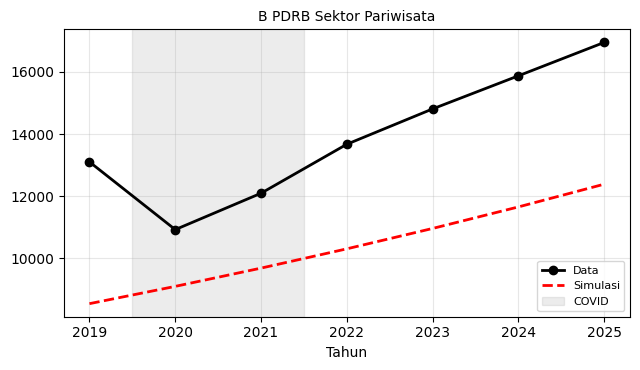

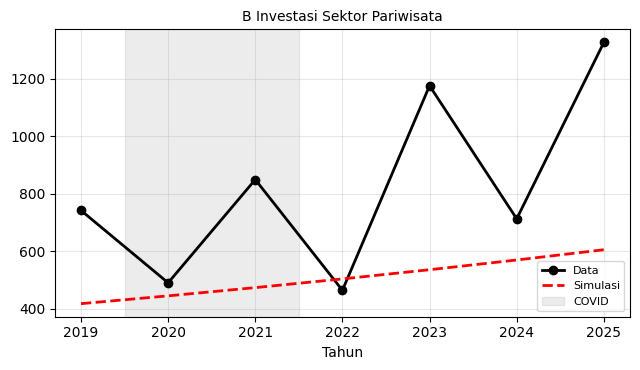

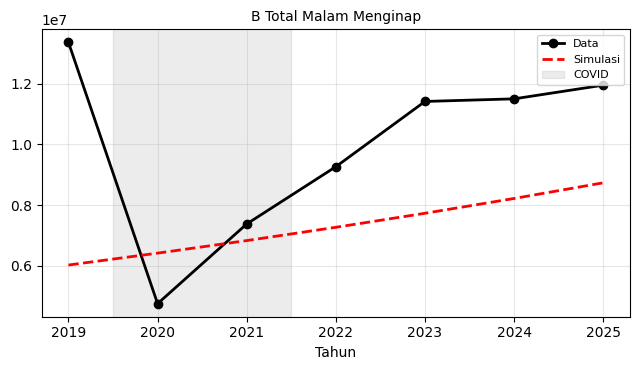

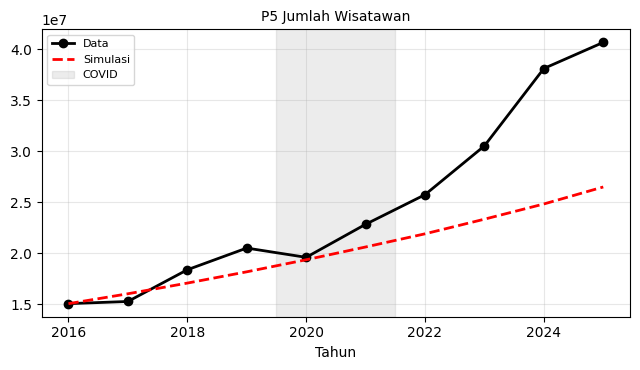

In [11]:
for nama, df in seri.items():
    fig, ax = plt.subplots(figsize=(6.5, 3.8))
    ax.plot(df["Tahun"], df["Data"], "ko-", lw=2, label="Data")
    ax.plot(df["Tahun"], df["Simulasi"], "r--", lw=2, label="Simulasi")
    ax.axvspan(2019.5, 2021.5, color="grey", alpha=0.15, label="COVID")
    ax.set_title(nama, fontsize=10); ax.set_xlabel("Tahun")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FOLDER / f"baseline_v2_{nama.replace(' ', '_')}.png", dpi=150)
    plt.show()
    plt.close(fig)

## Hasil yang seharusnya muncul (untuk pencocokan)

**P5 Jumlah Wisatawan:** tren berbeda nyata pada kedua versi; E1 0,1776 / 0,2025; E2 0,5767 / 0,5680; DC **0,4203 / 0,4057** (v1: 0,4362 / 0,4220).

**B, DC dengan COVID:** Wisatawan 0,4482; Hotel 0,8228; ODTW 0,7855; Tenaga Kerja 0,8860; Lahan 0,6619; TPK 0,6224; PDRB **0,3062**; Investasi 0,7356; Total Malam 0,7041.

Kalau ada selisih pada desimal ketiga, periksa dulu tiga hal: nilai TPK data (persen dibagi 100), faktor sambung 2,2997, dan penggunaan STDEV.P (bukan STDEV.S).